# L09 · NB 02 — Words to vectors

> *Before we use a pretrained model, let's build the intuition for what a vector representation of text actually means.*

The point: by the time you see a pretrained `SentenceTransformer` in NB 03, you should know exactly what mathematical object it's producing and why.

### 👟 Step into Sarah's shoes

**Where we left off (NB 01).** Sarah proved NorthStar's search is broken because it matches *spelling*, not *meaning* — to a keyword search, **frock ≠ dress**. The fix has to teach the computer that those words *mean* the same thing.

**But here's Sarah's honest problem:** a computer only does maths. It can't "understand" a word. So before she reaches for any fancy model, she wants to answer a more basic question for herself —

> *"How could a number possibly capture what a word means? And how would a computer ever figure out that 'frock' and 'dress' belong together — without me telling it?"*

**What Sarah wants to achieve here.** Build the intuition for **embeddings** (words as vectors) *from scratch, by hand*, so that when she plugs in a real pretrained model in NB 03 she knows exactly what mathematical object it's producing — and isn't treating it as magic.

**How she'll do it — each step is a deliberate experiment that fails forward:**

1. **One-hot vectors** — the dumbest possible "word → numbers". Watch it prove that every word is equally unrelated to every other (meaning = lost).
2. **Bag-of-words** — count words in a whole description. A step up, but it *still* can't connect synonyms.
3. **Co-occurrence embedding** — the key idea: *a word is known by the company it keeps.* Build this by hand and watch real similarity finally appear (cotton ≈ linen).
4. **Visualise in 2D** — see related words physically cluster. **This is the punchline: meaning becomes geometry.**

> Each step is designed to *fail in an instructive way*, so the next step's idea feels necessary instead of arbitrary. By the end Sarah has hand-built a tiny embedding — and understands why she needs a bigger, pretrained one (NB 03).

## 1 · Setup

In [11]:
import numpy as np  # numbers
import pandas as pd  # tables
import re
import matplotlib.pyplot as plt  # plots
from collections import Counter

np.random.seed(42)  # fix the random seed so results are repeatable
# Load data — local file if present (VS Code), else fetch from GitHub (works in Colab).
import os
_LOCAL = 'data/northstar_catalogue.csv'
_URL = 'https://raw.githubusercontent.com/su-ntu-ctp/6m-data-3.9-Natural-Language-Processing/main/notebooks/data/northstar_catalogue.csv'
df = pd.read_csv(_LOCAL if os.path.exists(_LOCAL) else _URL)  # load the same catalogue
print(f"Catalogue: {len(df)} products")

Catalogue: 76 products


## 2 · One-hot encoding — the naive baseline

The very first question: *how do we turn a word into numbers at all?* The simplest possible answer is **one-hot encoding**.

**The recipe:**
1. Collect every unique word in the catalogue into one big list — the **vocabulary**. Here it has **552** words.
2. Give each word a fixed seat number (an *index*) in that list, from 0 to 551.
3. To represent a word, write down 552 numbers that are **all 0 except a single 1** — placed in that word's seat.

> **Analogy: one light switch per word.** Picture a panel of 552 light switches in a row, one per vocabulary word. To represent `'frock'`, you flip ON *only* the switch at frock's seat and leave all 551 others OFF. Every word has its own switch, so no two words ever look alike — but the panel says nothing about which words *mean* similar things.

### How to read the output below

Each word prints a line like this:

```
'frock'  -> vector of (552,), sum=1, nonzero at index 188
```

Read it left to right:

| Part | Means |
|------|-------|
| `vector of (552,)` | The word became a list of **552 numbers** (one slot per vocabulary word). |
| `sum=1` | Adding up all 552 numbers gives **1** — confirming there's exactly **one** `1` and the rest are `0`. |
| `nonzero at index 188` | That single `1` sits in **slot 188** — frock's assigned seat. `dress` sits at 140, `gown` at 197: **different seats, nothing shared.** |

The last word is the interesting one:

```
'spaceship'  -> vector of (552,), sum=0, nonzero at index NONE
```

`sum=0` and `index NONE` mean **the word was never found** in the catalogue, so it has no seat — it becomes an all-zero vector. (A clothing shop has no reason to mention spaceships!) This is a real limitation: one-hot can only represent words it has already seen.

**The takeaway to carry into Step 3:** every real word gets a `1` in its own private slot and `0` everywhere else. Because no two words share a slot, the vectors give each word a unique *ID* but encode **zero information about meaning** — which is exactly the problem Step 3 exposes.

In [12]:
# One-hot encoding -- the dumbest way to turn a word into numbers.

def tokens(text):
    return re.findall(r'\w+', text.lower())

# Build vocabulary (every unique word) from BOTH name and description
vocab_counter = Counter()
for _, row in df.iterrows():
    vocab_counter.update(tokens(row['name'] + ' ' + row['description']))

VOCAB = sorted(vocab_counter.keys())
WORD_TO_IDX = {w: i for i, w in enumerate(VOCAB)}
V = len(VOCAB)
print(f"Vocabulary size: {V}")

# One-hot: a long list of 0s with a single 1 at the word's slot.
# Analogy: one light switch per word -- flip exactly one ON. A unique ID, but no meaning.
def onehot(word):
    v = np.zeros(V, dtype=np.float32)
    if word in WORD_TO_IDX:
        v[WORD_TO_IDX[word]] = 1.0
    return v

for w in ['frock', 'dress', 'gown', 'sundress', 'spaceship']:
    v = onehot(w)
    print(f"  {w!r:12s} -> vector of {v.shape}, sum={v.sum():.0f}, nonzero at index {np.argmax(v) if v.sum() > 0 else 'NONE'}")

Vocabulary size: 552
  'frock'      -> vector of (552,), sum=1, nonzero at index 188
  'dress'      -> vector of (552,), sum=1, nonzero at index 140
  'gown'       -> vector of (552,), sum=1, nonzero at index 197
  'sundress'   -> vector of (552,), sum=1, nonzero at index 462
  'spaceship'  -> vector of (552,), sum=0, nonzero at index NONE


## 3 · The equidistance problem

### First, what is cosine similarity?

We need a way to ask "how *similar* are two vectors?" The trick is to ignore how **long** the vectors are and look only at the **direction** they point.

Think of each vector as an **arrow** starting from the same spot:

- Two arrows pointing the **same way** → cosine **= 1.0** (identical direction, maximally similar).
- Two arrows at a **right angle** (90°) → cosine **= 0.0** (totally unrelated).
- Two arrows pointing **opposite** ways → cosine **= -1.0** (opposite).

> **Compass analogy.** Imagine each word is a hiker walking from camp. Cosine similarity asks: *are two hikers heading in the same compass direction?* It doesn't care whether one walked 1 km and the other 10 km — only whether they're going the **same way**. "North vs north" = 1.0. "North vs east" = 0.0.

Mathematically it's just the dot product divided by the two lengths — but the compass picture is all you need to read the numbers below.

### Now the problem

Compute cosine similarity between several pairs of **one-hot** vectors. Remember each one-hot vector has a single `1` in its own private slot and `0` everywhere else — like every word standing on its **own separate axis**.

Because no two words ever share a slot, every distinct pair sits at a perfect right angle → **cosine is always 0**.

> **Analogy.** It's like giving every word its own room in a hotel with the doors locked. "frock" is in room 188, "dress" in room 140, "spaceship" in room 451. From inside its locked room, "frock" has *no idea* whether its neighbour is "dress" or "spaceship" — every other room is just "somewhere else", equally far away.

That means "frock" is measured as **exactly as similar** to "dress" as it is to "spaceship". The numbers are mathematically tidy but meaning is completely lost.

In [13]:
# cosine() measures how similar two vectors are (1 = same direction, 0 = unrelated).
def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0: return 0.0
    return float(np.dot(a, b) / (na * nb))

pairs = [('frock', 'dress'), ('frock', 'gown'), ('frock', 'spaceship'), ('dress', 'dress')]
# Shocking result: every distinct one-hot pair scores 0.0 -- so 'frock' is exactly as similar
# to 'dress' as to 'spaceship'. One-hot knows identity, not meaning.
for a, b in pairs:
    sim = cosine(onehot(a), onehot(b))
    print(f"  cosine({a!r}, {b!r}) = {sim:.3f}")

  cosine('frock', 'dress') = 0.000
  cosine('frock', 'gown') = 0.000
  cosine('frock', 'spaceship') = 0.000
  cosine('dress', 'dress') = 1.000


Three different word pairs, three identical scores. The model has no notion of meaning.

## 4 · Bag-of-words (a small step up)

Represent an entire DOCUMENT as a vector of word *counts* — one count per vocab word. Two documents talking about the same topic with the same words will be close in this space.

In [14]:
# Bag-of-words: represent a whole description as a vector of word counts.
def bag_of_words(text):
    v = np.zeros(V, dtype=np.float32)
    for w in tokens(text):
        if w in WORD_TO_IDX:
            v[WORD_TO_IDX[w]] += 1
    return v

# Embed all product descriptions -- a step up, because two documents using the same words
# land near each other.
DESCRIPTIONS = (df['name'] + ' ' + df['description']).tolist()
bow_vecs = np.vstack([bag_of_words(d) for d in DESCRIPTIONS])
print(f"Bag-of-words matrix shape: {bow_vecs.shape}  (products × vocab)")
# Most entries are zero -- a SPARSE representation.
print(f"Density: {(bow_vecs > 0).mean():.2%} (most entries are zero — this is a SPARSE representation)")

Bag-of-words matrix shape: (76, 552)  (products × vocab)
Density: 2.11% (most entries are zero — this is a SPARSE representation)


### Now test bag-of-words as a search engine

In [15]:
# Test bag-of-words as a search engine.
def bow_search(query, top=5):
    q = bag_of_words(query)
    sims = np.array([cosine(q, bv) for bv in bow_vecs])
    order = np.argsort(-sims)[:top]
    return df.iloc[order].assign(score=sims[order])

# Still fails like keyword search: it only matches products that literally share the query's
# words, so the Lila frock stays buried. We need vectors that capture meaning.
print("Query: 'blue summer dress'")
print()
print(bow_search('blue summer dress')[['product_id','category','name','score']].to_string(index=False))

Query: 'blue summer dress'

product_id category                    name    score
     P0002    dress       Marina Wrap Dress 0.258199
     P0004    dress Holly Knit Jumper Dress 0.258199
     P0047 footwear Sand Espadrille Sandals 0.154303
     P0014    shirt       Frost Linen Shirt 0.154303
     P0007    dress    Sienna Bodycon Dress 0.149071


Same problem as keyword search — BoW only matches on shared content words. The Lila Floral Sundress (description: "lightweight floral frock") gets a low score because none of the **query words** appear in its description.

We need vectors that capture **meaning**, not just word presence.

## 5 · The embedding idea — co-occurrence

Here's the key insight (Firth, 1957): **words that appear in similar contexts tend to mean similar things.**

Build a co-occurrence matrix: for each word, count how often each other word appears within a small window around it across the whole corpus. Words that share many neighbours end up with similar count-vectors.

This is a toy version of Word2Vec / GloVe.

In [16]:
# The key idea (distributional hypothesis, Firth 1957): words used in similar contexts tend to
# mean similar things.

WINDOW = 5

# Slide a small window across every description and count which words appear near each other.
def build_cooccurrence(documents, vocab, window=WINDOW):
    V = len(vocab)
    word_to_idx = {w: i for i, w in enumerate(vocab)}
    M = np.zeros((V, V), dtype=np.float32)
    for doc in documents:
        toks = tokens(doc)
        for i, w in enumerate(toks):
            if w not in word_to_idx: continue
            wi = word_to_idx[w]
            for j in range(max(0, i-window), min(len(toks), i+window+1)):  # the window around word i
                if j == i: continue
                w2 = toks[j]
                if w2 not in word_to_idx: continue
                M[wi, word_to_idx[w2]] += 1
    return M

# Each word is now described by the company it keeps -- our first real embedding.
cooccur = build_cooccurrence(DESCRIPTIONS, VOCAB)
print(f"Co-occurrence matrix shape: {cooccur.shape}")
print(f"Density: {(cooccur > 0).mean():.2%}")

Co-occurrence matrix shape: (552, 552)
Density: 2.03%


Each ROW of `cooccur` is now a vector representing a word — but using its co-occurrence pattern, not just its identity.

### Try the cosine similarities again

In [17]:
# Re-run the similarity test with the co-occurrence vectors.
def word_vec(word):
    if word not in WORD_TO_IDX: return None
    return cooccur[WORD_TO_IDX[word]]

pairs = [
    ('frock', 'dress'),
    ('frock', 'gown'),
    ('dress', 'sundress'),
    ('frock', 'leather'),    # unrelated
    ('frock', 'trainers'),   # unrelated
    ('cotton', 'linen'),     # similar fabric -- scores ~0.38, real signal
    ('cotton', 'rubber'),    # different materials
]

# Real signal now: 'cotton' vs 'linen' is high while 'frock' vs 'trainers' stays near 0.
# ('frock' vs 'dress' is still low only because this tiny catalogue rarely uses both words
# together -- a real model fixes that.)
print(f"{'pair':30s} {'cosine':>8s}")
print('-' * 42)
for a, b in pairs:
    va, vb = word_vec(a), word_vec(b)
    sim = cosine(va, vb) if va is not None and vb is not None else float('nan')
    print(f"  {a!r:14s} {b!r:14s}  {sim:>6.3f}")

pair                             cosine
------------------------------------------
  'frock'        'dress'          0.035
  'frock'        'gown'           0.158
  'dress'        'sundress'       0.054
  'frock'        'leather'        0.000
  'frock'        'trainers'       0.071
  'cotton'       'linen'          0.378
  'cotton'       'rubber'         0.239


**Real differentiation, but partial.** Compare these numbers to the one-hot case where every pair was exactly 0:

- *cotton ↔ linen* gets a meaningful 0.378 — both fabrics, often described with overlapping adjectives (breathable, lightweight)
- *frock ↔ gown* sits at 0.158 — both garment words, some shared context
- *frock ↔ trainers* near 0 — different categories, different vocabulary
- But *frock ↔ dress* is only 0.035 — surprisingly low!

The low frock/dress similarity is a real limitation of our toy embedding: each PRODUCT description uses **only one** of these synonyms, so they rarely co-occur. The model picks up "fabrics share context" much more easily than "synonyms share context" on a tiny corpus.

This is exactly the gap that **pretrained sentence-transformers fix** — they're trained on billions of sentences where the same idea is paraphrased many different ways. Tomorrow you'll see frock/dress jump to about **0.25** — roughly 7× this toy embedding's 0.035, and a meaningful ranking signal even though it doesn't look like a big number. (Sentence-transformer cosines live in [0.2, 0.7]; read them as ranking, not percent.)

## 6 · Visualise the embedding in 2D

Each word's co-occurrence vector lives in 1000+ dimensional space. We can't see that, but we can project it down to 2D with PCA and look at how words cluster.

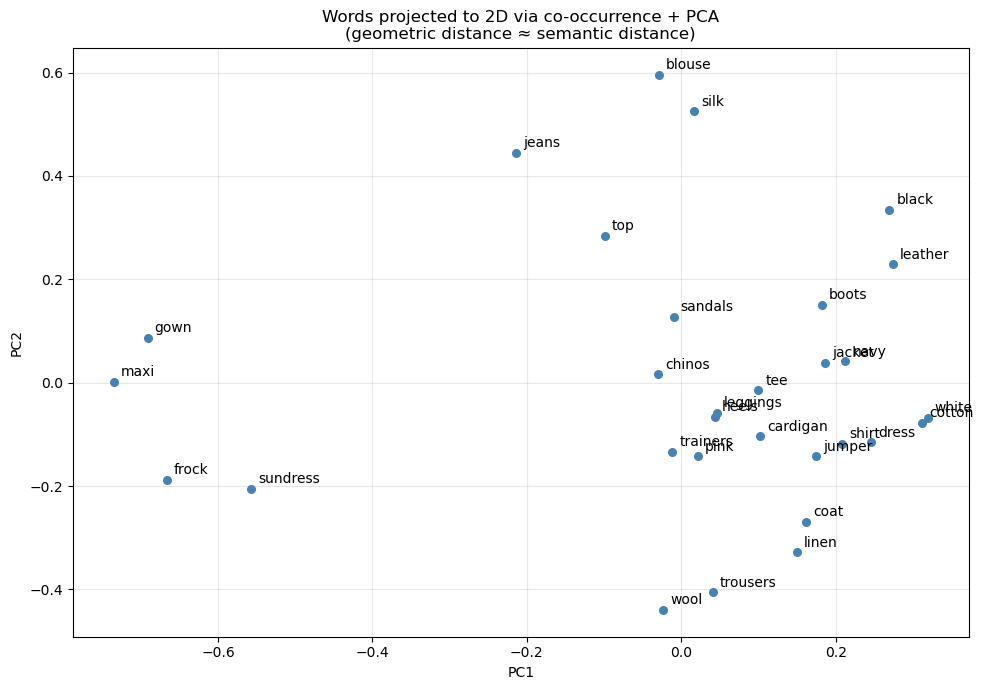

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# Pick a curated set of words from across categories
words_of_interest = [
    # dresses & related
    'dress', 'frock', 'gown', 'sundress', 'maxi',
    # tops
    'shirt', 'blouse', 'tee', 'top',
    # legs
    'trousers', 'chinos', 'leggings', 'jeans',
    # outerwear
    'coat', 'jacket', 'jumper', 'cardigan',
    # footwear
    'boots', 'trainers', 'sandals', 'heels',
    # fabrics
    'cotton', 'linen', 'wool', 'silk', 'leather',
    # colours
    'navy', 'black', 'white', 'pink',
]
# keep only those in our vocabulary
words_of_interest = [w for w in words_of_interest if w in WORD_TO_IDX]
# each word vector lives in 1000+ dimensions, which we cannot see
vecs = np.vstack([word_vec(w) for w in words_of_interest])

vecs_n = normalize(vecs)
pca = PCA(n_components=2)
coords = pca.fit_transform(vecs_n)  # squash to 2-D, like flattening a globe onto a flat map

# Plot -- fabric / garment / footwear words start to cluster. That clustering is meaning you can see.
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(coords[:, 0], coords[:, 1], s=30, c='steelblue', zorder=2)
for i, w in enumerate(words_of_interest):
    ax.annotate(w, coords[i], xytext=(5, 4), textcoords='offset points', fontsize=10)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Words projected to 2D via co-occurrence + PCA\n(geometric distance ≈ semantic distance)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Look at the plot. Even with our tiny 76-document corpus you should see some partial clustering — fabric words tend to live in one region, garment words in another, footwear words mostly together. The clustering is **noisy** because the corpus is small, but the geometry is real.

In NB 03 we'll project a pretrained model's embeddings the same way and see much tighter clusters — that's what training on a billion sentences buys you.

**Key point regardless of size:** the model was never told the categories. It deduced them purely from which words tend to appear near each other. *This is meaning, expressed as geometry.* That's all an embedding is.

## 7 · Limitations of our toy embedding

Our hand-built co-occurrence vectors are real embeddings, but tiny ones. Limitations:

- **Vocabulary**: only words from THIS catalogue. Unknown words → no vector.
- **Static**: every occurrence of "bank" gets the same vector regardless of context.
- **Sparse and noisy**: 76 product descriptions is a tiny corpus. Real models train on billions of words.
- **Word-level**: we have vectors for words, not sentences. To embed a query, we'd have to average word vectors and lose word-order information.

The modern fix to all four problems is **transformer-based sentence-encoders** like the one we use in NB 03. Pretrained on >1B sentences. 30,000-token subword vocabulary. Context-aware (each word's vector depends on its neighbours). Sentence-level output.

You've now built one by hand. Tomorrow you'll plug in one that's a million times bigger.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## E1 · Try your own word pairs

Pick five word pairs from the catalogue and compute their cosine similarity. Do the numbers match your intuition? Where does the embedding surprise you (positively or negatively)?

In [19]:
# (Optional) Try any word pairs that interest you and see if the numbers match intuition.
your_pairs = [
    ('boots', 'trainers'),
    ('boots', 'sandals'),
    ('cotton', 'wool'),
    ('summer', 'winter'),   # the toy model handles antonyms poorly -- opposites appear in
    ('cosy', 'warm'),       # similar contexts, so they end up close despite being opposites
]
for a, b in your_pairs:
    va, vb = word_vec(a), word_vec(b)
    sim = cosine(va, vb) if va is not None and vb is not None else float('nan')
    print(f"  cosine({a!r:10s}, {b!r:10s}) = {sim:.3f}")

  cosine('boots'   , 'trainers') = 0.131
  cosine('boots'   , 'sandals' ) = 0.269
  cosine('cotton'  , 'wool'    ) = 0.147
  cosine('summer'  , 'winter'  ) = 0.188
  cosine('cosy'    , 'warm'    ) = 0.000


Notice some hits and some misses. Our embedding doesn't capture antonyms well (summer/winter often appear in similar contexts so they end up close). Real sentence-transformers handle this better, but the limitation is fundamental — the distributional hypothesis says "company you keep", and opposites often keep similar company.

## E2 · A smaller embedding via SVD

The co-occurrence rows are huge (1000+ dim). Use SVD (Singular Value Decomposition) to compress to a much smaller dense embedding — this is essentially the GloVe approach.

In [20]:
from sklearn.decomposition import TruncatedSVD

# (Optional) SVD compresses each huge word vector to 50 dense numbers while keeping most of the
# meaning -- essentially how real models like GloVe work: dense and low-dimensional.
svd = TruncatedSVD(n_components=50, random_state=42)
dense_vecs = svd.fit_transform(cooccur)
print(f"Dense embedding shape: {dense_vecs.shape}  (vocab × 50)")
print(f"Variance explained by top 50 components: {svd.explained_variance_ratio_.sum():.2%}")

def dense_vec(word):
    if word not in WORD_TO_IDX: return None
    return dense_vecs[WORD_TO_IDX[word]]

# Same pairs as before — does compression hurt?
print("\n50-dim dense vectors:")
for a, b in [('frock','dress'), ('frock','gown'), ('cotton','linen'), ('frock','trainers')]:
    va, vb = dense_vec(a), dense_vec(b)
    print(f"  cosine({a!r:10s}, {b!r:10s}) = {cosine(va, vb):.3f}")

Dense embedding shape: (552, 50)  (vocab × 50)
Variance explained by top 50 components: 74.30%

50-dim dense vectors:
  cosine('frock'   , 'dress'   ) = 0.036
  cosine('frock'   , 'gown'    ) = 0.229
  cosine('cotton'  , 'linen'   ) = 0.402
  cosine('frock'   , 'trainers') = 0.110


Compressed embeddings preserve most of the meaning while being much faster to work with. Real models (Word2Vec, GloVe, MiniLM) output 100-768 dim vectors — never the full vocabulary size. Dense + low-dim is the modern default.